# Definitive way to save npy

In [1]:
import os
import numpy as np
import cv2
import zlib
import base64
import json
import matplotlib.pyplot as plt

In [2]:
def base64_2_mask(s):
    z = zlib.decompress(base64.b64decode(s))
    n = np.fromstring(z, np.uint8)
    mask = cv2.imdecode(n, cv2.IMREAD_UNCHANGED)
    return mask[:, :, 3] 

In [10]:
# Define the path to the folder containing the JSON files
json_folder_path = '/home/giordano_vitale/ETE-Thesis-2024-ML-002/LoveDA/val/ann/'

In [8]:
num_classes = 6

In [11]:
# Loop through each file in the folder
for filename in os.listdir(json_folder_path):
    if filename.endswith('.png.json'):
        json_path = os.path.join(json_folder_path, filename)
        
        # Load the JSON file
        with open(json_path) as json_file:
            labels = json.load(json_file)

        # Extract masks, origins, and class IDs
        mask_str = []
        origins = []
        class_ids = []

        for i in range(len(labels['objects'])):
            mask_str.append(labels['objects'][i]['bitmap']['data'])
            origins.append(labels['objects'][i]['bitmap']['origin'])
            class_ids.append(labels['objects'][i]['classId'])

        # Create a blank 1024x1024 mask
        final_mask = np.zeros((1024, 1024), dtype=np.uint16)  
        
        # Iterate over each class in the image
        for i in range(len(class_ids)):
            class_id = class_ids[i]
            origin = origins[i]
            
            # Decode the mask from base64
            mask_small = base64_2_mask(mask_str[i])
            
            # Place the mask in the correct position on the 1024x1024 canvas
            mask_region = final_mask[
                origin[1]:origin[1] + mask_small.shape[0], 
                origin[0]:origin[0] + mask_small.shape[1]
            ]
            
            # Apply the class ID to the mask region, considering potential overlaps
            mask_region[mask_small > 0] = class_id

            # Update the final mask
            final_mask[
                origin[1]:origin[1] + mask_small.shape[0], 
                origin[0]:origin[0] + mask_small.shape[1]
            ] = mask_region

        # Replace the ClassIDs with the class labels
        final_mask[final_mask == 26251] = 0 # Background
        final_mask[final_mask == 26252] = 1 # building
        final_mask[final_mask == 26253] = 2 # road
        final_mask[final_mask == 26254] = 3 # water
        final_mask[final_mask == 26255] = 4 # barren
        final_mask[final_mask == 26256] = 5 # forest
        final_mask[final_mask == 26257] = 4 # agriculture

        # Initialize the one-hot encoded mask with zeros
        one_hot_mask = np.zeros((final_mask.shape[0], 
                                 final_mask.shape[1], 
                                 num_classes), dtype=np.uint8)
        
        # Populate the one-hot encoded mask on its corresponding channel
        for value in np.unique(final_mask):
            one_hot_mask[:, :, value] = (final_mask == value).astype(np.uint8)
        
        # save the final mask as an image
        new_path = "/home/giordano_vitale/ETE-Thesis-2024-ML-002/NoBarren/val/masks/"
        output_path = os.path.join(new_path, filename.replace('.png.json', '.png'))
        plt.imsave(output_path, final_mask)

        # Save the final_mask as npy arrays
        output_path = os.path.join(new_path, filename.replace('.png.json', '.npy'))
        np.save(output_path, one_hot_mask)

/tmp/ipykernel_1455126/2432005838.py:3: DeprecationWarning: The binary mode of fromstring is deprecated, as it behaves surprisingly on unicode inputs. Use frombuffer instead
  n = np.fromstring(z, np.uint8)


In [7]:
# Save the images as npy arrays

folder_path = "/home/giordano_vitale/ETE-Thesis-2024-ML-002/LoveDA/val/masks/"
for filename in os.listdir(folder_path):
    if filename.endswith('.png'):
        img = cv2.imread(os.path.join(folder_path, filename))
        img_array = np.array(img)
        output_path = os.path.join(folder_path, filename.replace('.png', '.npy'))
        np.save(output_path, img_array)

## Example mask

In [3]:
example_image = np.load('/home/giordano_vitale/ETE-Thesis-2024-ML-002/LoveDA/val/img/2522.npy')

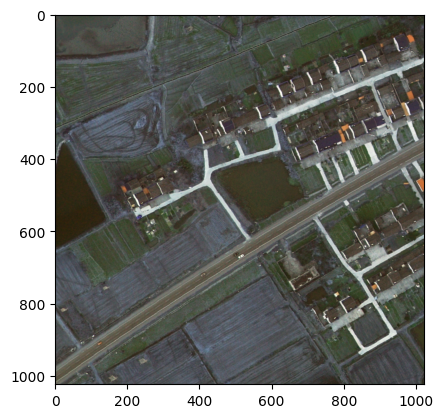

In [4]:
plt.imshow(example_image)

In [6]:
example_mask = np.load('/home/giordano_vitale/ETE-Thesis-2024-ML-002/LoveDA/val/masks/2522.npy')

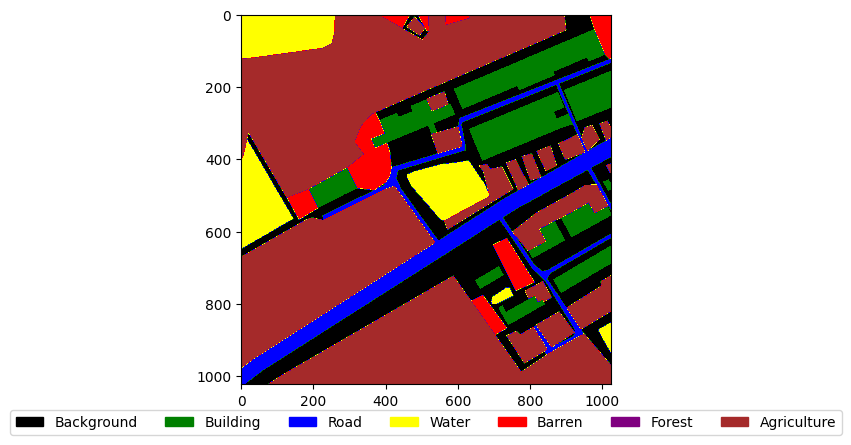

In [8]:
from matplotlib.colors import ListedColormap
cmap = ListedColormap(['black', 'green', 'blue', 'yellow', 'red', 'purple', 'brown'])
class_names = ['Background', 'Building', 'Road', 'Water', 'Barren', 'Forest', 'Agriculture']
import matplotlib.patches as mpatches

plt.imshow(np.argmax(example_mask, axis=-1), cmap=cmap)
legend_patches = [mpatches.Patch(color=cmap(i), label=class_names[i]) for i in range(len(class_names))]
plt.legend(handles=legend_patches, loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=7)
plt.show()

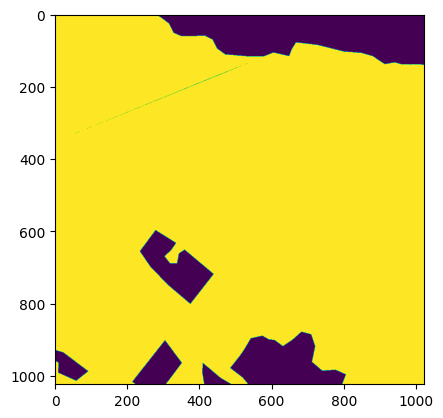

In [34]:
example_binary_mask = np.load('/home/giordano_vitale/ETE-Thesis-2024-ML-002/Binary_Forest/train/masks/2.npy')
plt.imshow(np.argmax(example_binary_mask, axis=-1))

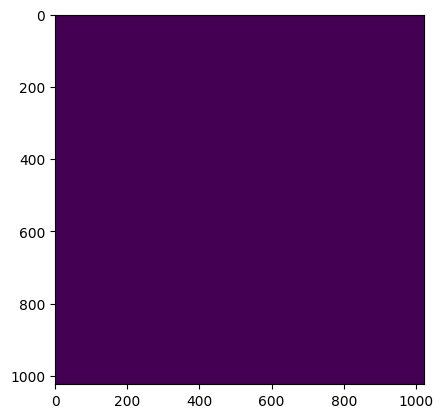

In [39]:
plt.imshow(example_binary_mask[...,5])

Text(0.5, 0.98, 'Single classes displayed separately - white areas represent the class')

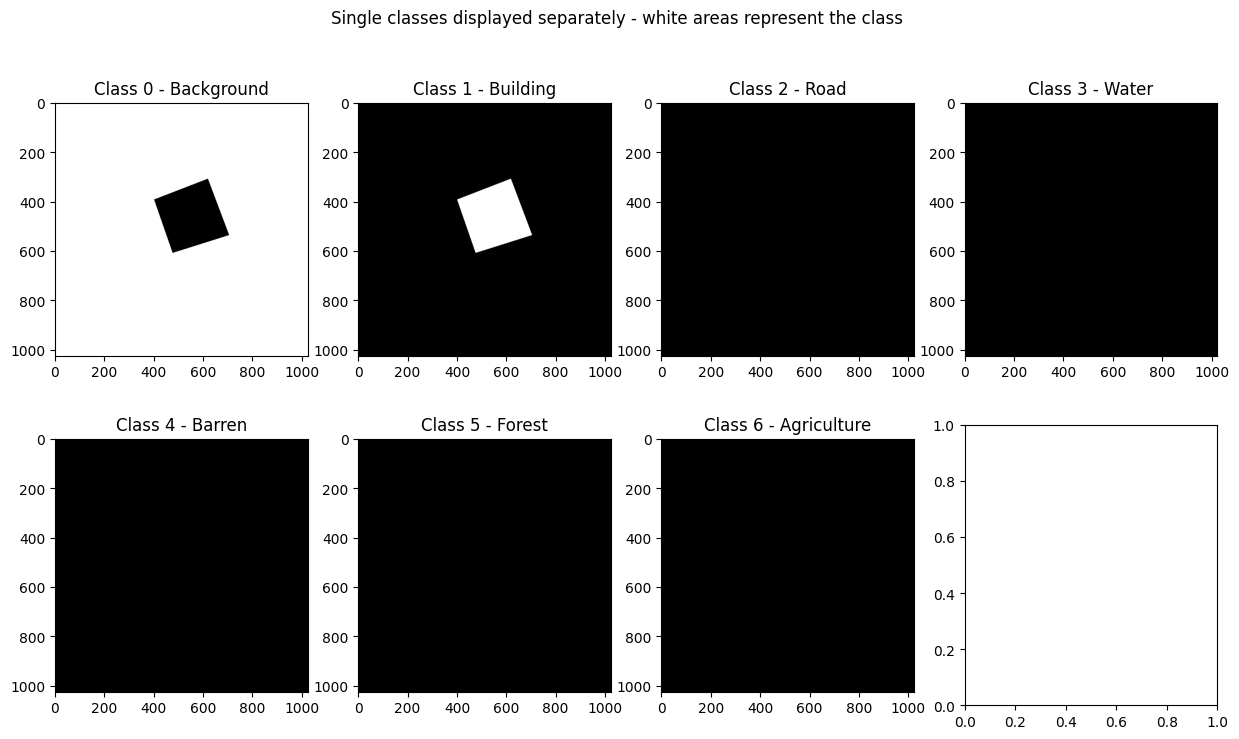

In [17]:
fig, axs = plt.subplots(2, 4, figsize=(15, 8))

axs[0,0].imshow(example[:, :, 0], cmap='gray')
axs[0,0].set_title('Class 0 - Background')

axs[0,1].imshow(example[:, :, 1], cmap='gray')
axs[0,1].set_title('Class 1 - Building')

axs[0,2].imshow(example[:, :, 2], cmap='gray')
axs[0,2].set_title('Class 2 - Road')

axs[0,3].imshow(example[:, :, 3], cmap='gray')
axs[0,3].set_title('Class 3 - Water')

axs[1,0].imshow(example[:, :, 4], cmap='gray')
axs[1,0].set_title('Class 4 - Barren')

axs[1,1].imshow(example[:, :, 5], cmap='gray')
axs[1,1].set_title('Class 5 - Forest')

axs[1,2].imshow(example[:, :, 6], cmap='gray')
axs[1,2].set_title('Class 6 - Agriculture')

fig.suptitle('Single classes displayed separately - white areas represent the class')